# The Pace of Life

**Nguồn dữ liệu:** R.V. Levine, "The Pace of Life", *American Scientist* 78 (1990): 450–59.

## Bối cảnh
Một giả thuyết phổ biến trong tâm lý học cho rằng những người luôn có cảm giác gấp gáp về thời gian
(hành vi *type-A*) dễ mắc bệnh tim hơn những người sống thong thả (*type-B*). Để kiểm định giả thuyết này
ở cấp độ thành phố, các nhà nghiên cứu đã chọn 36 thành phố của Mỹ (mỗi vùng miền chọn 3 đô thị lớn, 3 đô
thị vừa, 3 đô thị nhỏ) và đo 3 chỉ số phản ánh nhịp sống:

- **Walk** — tốc độ đi bộ của người đi đường trên quãng đường 20 mét trong giờ hành chính (chỉ số càng cao ⇒ đi càng nhanh ⇒ nhịp sống càng gấp gáp).
- **Bank** — thời gian trung bình một nhân viên ngân hàng trả tiền thối cho 2 tờ 20 đô-la (chỉ số càng cao ⇒ xử lý càng chậm ⇒ nhịp sống càng thong thả, ngược hướng với Walk/Talk).
- **Talk** — tốc độ nói của nhân viên bưu điện, đo bằng số âm tiết chia cho thời gian trả lời (chỉ số càng cao ⇒ nói càng nhanh ⇒ nhịp sống càng gấp gáp).

Đồng thời, nhóm nghiên cứu thu thập **Heart** — tỷ lệ tử vong do bệnh tim đã hiệu chỉnh theo tuổi của mỗi
thành phố.

## Câu hỏi nghiên cứu
> Dữ liệu có ủng hộ hay bác bỏ niềm tin rằng những người có cảm giác gấp gáp về thời gian dễ mắc bệnh
> tim hơn không?

## Các bước nghiên cứu phân tích
1. Thống kê mô tả và kiểm tra chất lượng dữ liệu.
2. Phân tích tương quan Pearson giữa từng chỉ số nhịp sống và Heart.
3. Trực quan hoá: scatterplot, ma trận tương quan, pairplot.
4. Hồi quy tuyến tính bội `Heart ~ Walk + Bank + Talk` và kiểm tra các giả định hồi quy (đa cộng
   tuyến, phân phối phần dư, phương sai đồng nhất, điểm ảnh hưởng).
5. Xây dựng chỉ số nhịp sống tổng hợp (composite pace-of-life index) và hồi quy đơn biến với Heart để
   có một phép kiểm định tổng hợp, dễ diễn giải.
6. Ước lượng hồi quy tuyến tính Bayes cho cùng mô hình `Heart ~ Walk + Bank + Talk`: đặt prior liên
   hợp Normal-Inverse-Gamma, suy ra hậu nghiệm dạng đóng, lấy mẫu hậu nghiệm bằng Gibbs sampling (MCMC),
   chẩn đoán hội tụ (trace plot, Gelman-Rubin R-hat) và đối chiếu với ước lượng tần suất (OLS).
7. Đánh giá kết quả (tần suất + Bayes), trả lời câu hỏi nghiên cứu và nêu các giới hạn của phân tích.


In [1]:
# --- Nạp các thư viện cần thiết ---
import pandas as pd            # xử lý bảng dữ liệu (DataFrame)
import numpy as np              # đại số tuyến tính / mảng số (dùng ở phần Bayes)
import scipy.stats as stats     # hàm thống kê: pearsonr, zscore, shapiro...
import statsmodels.api as sm    # hồi quy OLS tần suất + các kiểm định chẩn đoán
from statsmodels.stats.outliers_influence import variance_inflation_factor  # tính VIF (đa cộng tuyến)
from statsmodels.stats.stattools import jarque_bera
import matplotlib.pyplot as plt  # vẽ biểu đồ
import seaborn as sns            # biểu đồ thống kê (đẹp hơn matplotlib thuần)
import os

# Thiết lập style chung cho tất cả biểu đồ trong notebook
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid', palette='deep')

# Thư mục lưu các file hình ảnh (.png) xuất ra từ notebook
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option('display.precision', 3)  # làm tròn 3 chữ số thập phân khi in DataFrame


## 1. Nạp và kiểm tra dữ liệu

In [2]:
# Đọc dữ liệu từ file CSV gốc
df = pd.read_csv('../data/pace_of_life.csv')
print(f"So thanh pho: {df.shape[0]}, so bien: {df.shape[1]}")
df.head(10)  # xem thử 10 dòng đầu để kiểm tra dữ liệu đọc đúng định dạng


So thanh pho: 36, so bien: 5


,City,Walk,Bank,Talk,Heart
0,Boston,28,31,24,24
1,Buffalo,23,30,23,29
2,New York,24,29,18,31
3,Salt Lake City,28,28,23,26
4,Columbus,22,27,30,26
5,Worcester,25,26,24,20
6,Providence,26,30,24,17
7,Springfield,30,28,21,19
8,Rochester,22,33,18,26
9,Kansas City,22,33,22,24


In [3]:
# Kiểm tra kiểu dữ liệu từng cột và phát hiện giá trị khuyết (missing value)
df.info()
print()
print("So gia tri thieu theo cot:")
print(df.isna().sum())  # đếm số ô trống (NaN) trong từng cột - kỳ vọng = 0


<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   City    36 non-null     str  
 1   Walk    36 non-null     int64
 2   Bank    36 non-null     int64
 3   Talk    36 non-null     int64
 4   Heart   36 non-null     int64
dtypes: int64(4), str(1)
memory usage: 1.5 KB

So gia tri thieu theo cot:
City     0
Walk     0
Bank     0
Talk     0
Heart    0
dtype: int64


**Nhận xét:** Dữ liệu có 36 thành phố, đúng như mô tả gốc của Levine, không có giá trị khuyết. Cả 4 biến
định lượng đều đã được đưa về thang đo không đơn vị (theo ghi chú gốc của bộ dữ liệu).

## 2. Thống kê mô tả

In [4]:
# Thống kê mô tả: trung bình, độ lệch chuẩn, min/max, các tứ phân vị (describe())
desc = df[['Walk', 'Bank', 'Talk', 'Heart']].describe().T
desc['skew'] = df[['Walk', 'Bank', 'Talk', 'Heart']].skew()  # độ lệch (skewness) để kiểm tra tính đối xứng
desc


,count,mean,std,min,25%,50%,75%,max,skew
Walk,36.0,21.417,4.285,12.0,18.75,22.0,23.25,30.0,-0.297
Bank,36.0,26.361,4.409,13.0,24.00,26.5,29.25,34.0,-0.665
Talk,36.0,20.750,4.129,10.0,18.00,22.0,23.25,30.0,-0.515
Heart,36.0,19.806,5.214,11.0,16.00,19.0,24.00,31.0,0.163


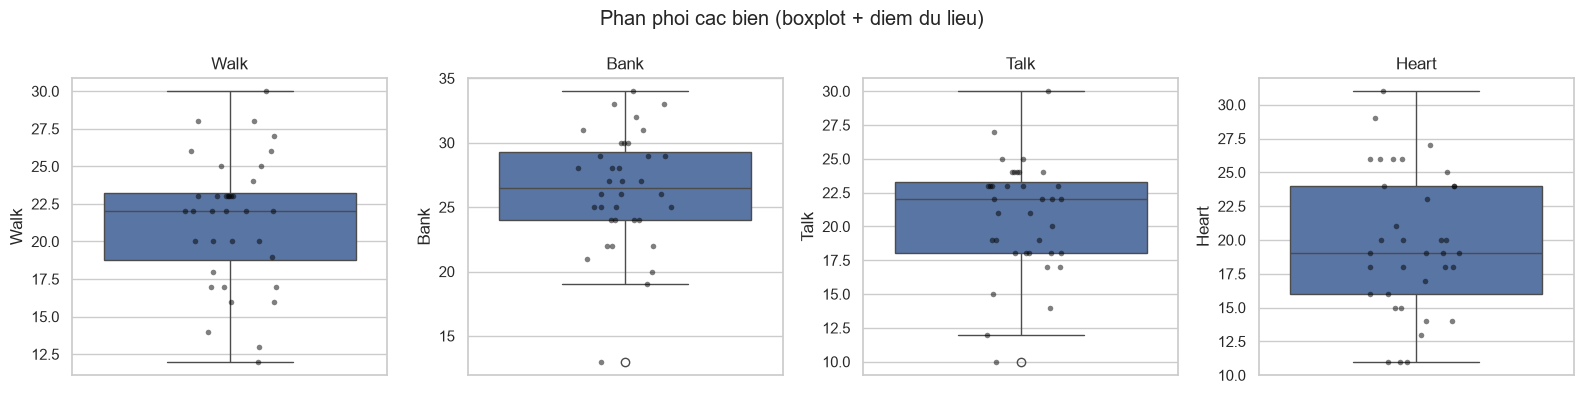

In [5]:
# Vẽ boxplot + điểm dữ liệu (strip plot) cho cả 4 biến để quan sát trực quan phân phối và ngoại lai
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['Walk', 'Bank', 'Talk', 'Heart']):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    sns.stripplot(y=df[col], ax=ax, color='black', alpha=0.5, size=4, jitter=0.15)  # chồng đè lên boxplot
    ax.set_title(col)
plt.suptitle('Phan phoi cac bien (boxplot + diem du lieu)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_boxplots.png', dpi=150)  # lưu hình để đưa vào báo cáo
plt.show()


## 3. Chỉ số nhịp sống tổng hợp (Pace-of-Life Index)

Vì `Bank` đo **thời gian xử lý** (càng cao càng chậm) trong khi `Walk` và `Talk` đo **tốc độ** (càng cao
càng nhanh), ta cần đảo dấu `Bank` trước khi kết hợp ba chỉ số thành một thước đo "nhịp sống gấp gáp"
(time urgency) duy nhất. Mỗi biến được chuẩn hoá (z-score) trước khi cộng để tránh một biến có phương sai
lớn hơn lấn át các biến khác.

In [6]:
# Chuẩn hoá z-score cho Walk, Bank, Talk: z = (x - trung_bình) / độ_lệch_chuẩn
z = df[['Walk', 'Bank', 'Talk']].apply(stats.zscore)

# Đảo dấu z(Bank) vì Bank đo THỜI GIAN xử lý (cao = chậm), ngược hướng với Walk/Talk (cao = nhanh)
# Pace_Index = trung bình cộng của 3 z-score (đã đảo dấu Bank) -> chỉ số "nhịp sống gấp gáp" gộp
df['Pace_Index'] = (z['Walk'] + (-z['Bank']) + z['Talk']) / 3

# 5 thành phố có Pace_Index cao nhất (nhịp sống "gấp gáp" nhất theo chỉ số gộp này)
df[['City', 'Walk', 'Bank', 'Talk', 'Pace_Index', 'Heart']].sort_values('Pace_Index', ascending=False).head(5)


,City,Walk,Bank,Talk,Pace_Index,Heart
14,Atlanta,27,25,27,1.057,19
4,Columbus,22,27,30,0.754,26
18,Chicago,23,24,25,0.654,20
10,St Louis,23,22,23,0.644,26
29,East Lansing,23,22,23,0.644,21


## 4. Phân tích tương quan

In [7]:
# Ma trận hệ số tương quan Pearson giữa tất cả các biến (gồm cả Pace_Index)
vars_ = ['Walk', 'Bank', 'Talk', 'Pace_Index', 'Heart']
corr = df[vars_].corr(method='pearson')
corr


,Walk,Bank,Talk,Pace_Index,Heart
Walk,1.000,0.067,0.327,0.751,0.348
Bank,0.067,1.000,0.352,-0.346,0.318
Talk,0.327,0.352,1.000,0.581,0.100
Pace_Index,0.751,-0.346,0.581,1.000,0.077
Heart,0.348,0.318,0.100,0.077,1.000


In [8]:
# Tương quan Pearson của TỪNG biến với Heart, kèm p-value kiểm định H0: r = 0
print("Tuong quan Pearson voi Heart (kem kiem dinh y nghia thong ke, alpha = 0.05)")
print("-" * 65)
for col in ['Walk', 'Bank', 'Talk', 'Pace_Index']:
    r, p = stats.pearsonr(df[col], df['Heart'])  # r: hệ số tương quan, p: p-value hai phía
    sig = 'co y nghia' if p < 0.05 else 'khong co y nghia'
    direction = 'thuan (+)' if r > 0 else 'nghich (-)'
    print(f"{col:12s} r = {r:+.3f}   p = {p:.4f}   -> tuong quan {direction}, {sig}")


Tuong quan Pearson voi Heart (kem kiem dinh y nghia thong ke, alpha = 0.05)
-----------------------------------------------------------------
Walk         r = +0.348   p = 0.0377   -> tuong quan thuan (+), co y nghia
Bank         r = +0.318   p = 0.0591   -> tuong quan thuan (+), khong co y nghia
Talk         r = +0.100   p = 0.5623   -> tuong quan thuan (+), khong co y nghia
Pace_Index   r = +0.077   p = 0.6535   -> tuong quan thuan (+), khong co y nghia


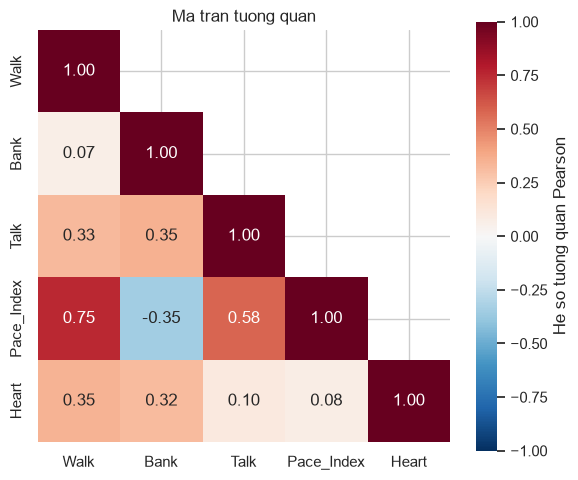

In [9]:
# Vẽ heatmap ma trận tương quan (chỉ hiện nửa tam giác dưới để tránh lặp thông tin)
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mask phần tam giác trên (bỏ k=1: giữ đường chéo)
sns.heatmap(corr, mask=~np.tril(np.ones_like(corr, dtype=bool)) & mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, square=True, cbar_kws={'label': 'He so tuong quan Pearson'})
plt.title('Ma tran tuong quan')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_correlation_heatmap.png', dpi=150)
plt.show()


**Diễn giải chiều tương quan (lưu ý `Bank` đo thời gian xử lý, không phải tốc độ; giả thuyết type-A dự
đoán Heart tăng khi Walk tăng, Talk tăng và Bank GIẢM):**

- `Walk`: r = +0.348, p = 0.038 (**có ý nghĩa**) — đúng chiều giả thuyết.
- `Talk`: r = +0.100, p = 0.562 (không có ý nghĩa) — đúng chiều nhưng quá yếu.
- `Bank`: r = +0.318, p = 0.059 (cận biên) — **ngược** chiều giả thuyết: xử lý giao dịch càng chậm (nhịp
  sống càng thong thả) lại đi kèm Heart càng cao. Vì vậy khi đảo dấu Bank để đưa vào `Pace_Index`, thành
  phần này kéo chỉ số tổng hợp về hướng ngược với Walk và Talk.
- `Pace_Index`: r = +0.077, p = 0.654 (không có ý nghĩa) — hệ quả của việc Walk/Talk và Bank triệt tiêu
  lẫn nhau.

## 5. Scatterplot: Heart theo từng chỉ số nhịp sống

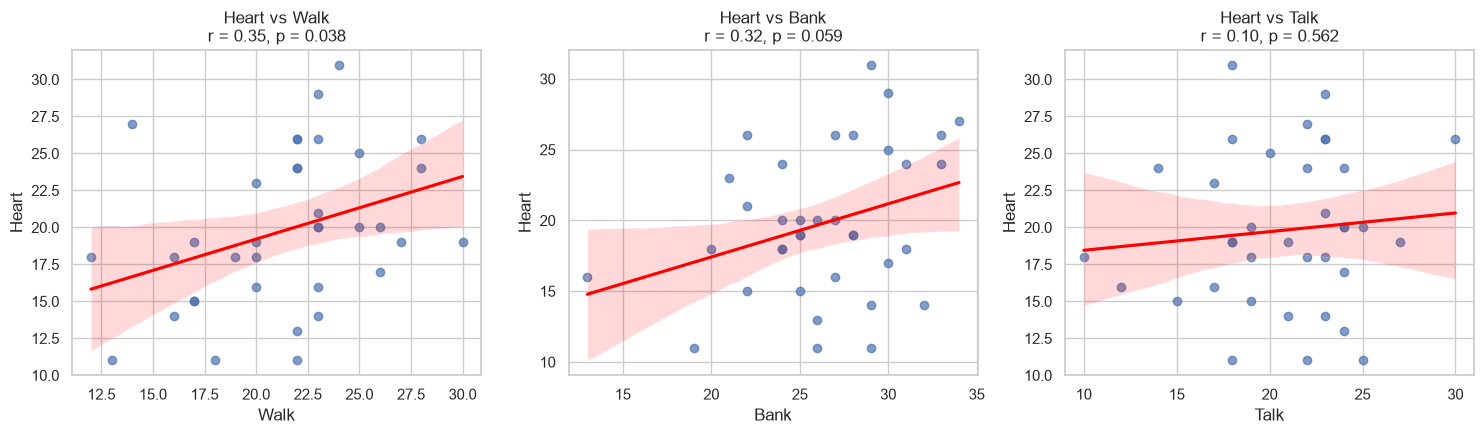

In [10]:
# Scatterplot Heart theo từng biến giải thích (Walk, Bank, Talk), kèm đường hồi quy tuyến tính đơn biến
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['Walk', 'Bank', 'Talk']):
    sns.regplot(data=df, x=col, y='Heart', ax=ax, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
    r, p = stats.pearsonr(df[col], df['Heart'])
    ax.set_title(f'Heart vs {col}\nr = {r:.2f}, p = {p:.3f}')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_scatter_predictors.png', dpi=150)
plt.show()


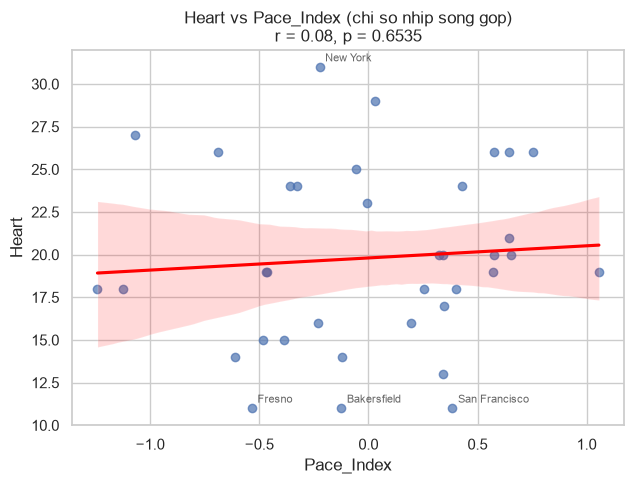

In [11]:
# Scatterplot Heart theo chỉ số nhịp sống tổng hợp Pace_Index
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.regplot(data=df, x='Pace_Index', y='Heart', ax=ax, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
r, p = stats.pearsonr(df['Pace_Index'], df['Heart'])
ax.set_title(f'Heart vs Pace_Index (chi so nhip song gop)\nr = {r:.2f}, p = {p:.4f}')

# Gán nhãn tên thành phố cho các điểm "cực trị" (Pace_Index hoặc Heart ở mức bất thường) để dễ đối chiếu
for _, row in df.iterrows():
    if abs(row['Pace_Index']) > 1.3 or row['Heart'] > 29 or row['Heart'] < 12:
        ax.annotate(row['City'], (row['Pace_Index'], row['Heart']), fontsize=8, alpha=0.7,
                    xytext=(4, 4), textcoords='offset points')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_scatter_pace_index.png', dpi=150)
plt.show()


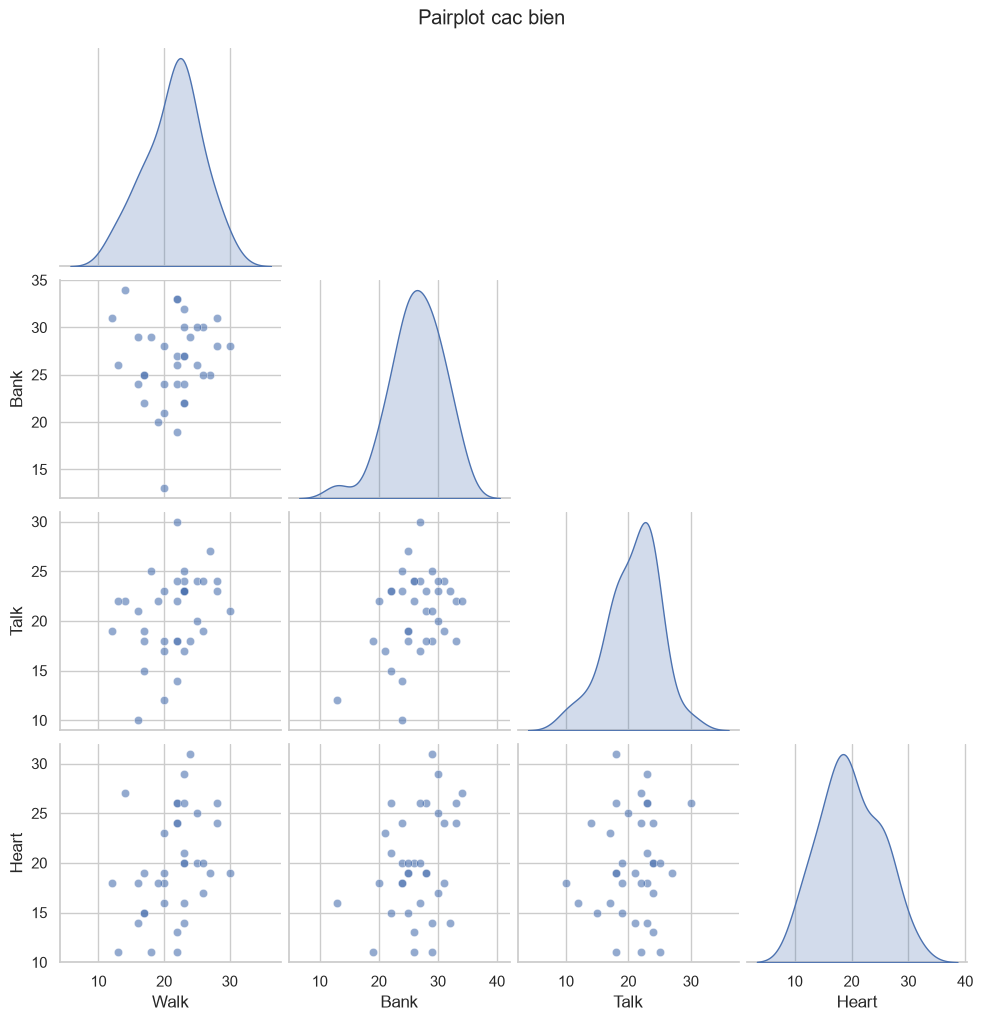

In [12]:
# Pairplot: ma trận scatterplot đôi 1-1 giữa các biến, đường chéo là biểu đồ mật độ (KDE)
g = sns.pairplot(df[['Walk', 'Bank', 'Talk', 'Heart']], corner=True, diag_kind='kde',
                  plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot cac bien', y=1.02)
g.savefig(f'{FIG_DIR}/05_pairplot.png', dpi=150)
plt.show()


## 6. Hồi quy tuyến tính bội: `Heart ~ Walk + Bank + Talk`

In [13]:
# ===== ƯỚC LƯỢNG TẦN SUẤT (OLS) cho mô hình Heart ~ Walk + Bank + Talk =====
X = df[['Walk', 'Bank', 'Talk']]
X = sm.add_constant(X)   # thêm cột hằng số (intercept) vào ma trận thiết kế X
y = df['Heart']

model = sm.OLS(y, X).fit()   # ước lượng bình phương tối thiểu (Ordinary Least Squares)
print(model.summary())        # in bảng kết quả đầy đủ: hệ số, sai số chuẩn, t, p-value, R^2, F-test...


                            OLS Regression Results                            
Dep. Variable:                  Heart   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     3.073
Date:                Thu, 08 Oct 2026   Prob (F-statistic):             0.0416
Time:                        11:39:18   Log-Likelihood:                -105.47
No. Observations:                  36   AIC:                             218.9
Df Residuals:                      32   BIC:                             225.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1787      6.337      0.502      0.6

**Cách đọc kết quả:**
- `R-squared` / `Adj. R-squared`: tỷ lệ phương sai của `Heart` được giải thích bởi 3 biến nhịp sống.
- `F-statistic` và `Prob (F-statistic)`: kiểm định ý nghĩa tổng thể của mô hình (H0: tất cả hệ số hồi
  quy = 0).
- Với mỗi biến, cột `coef` là hệ số hồi quy riêng phần (kiểm soát 2 biến còn lại), `P>|t|` là p-value
  kiểm định `H0: beta = 0`.

### 6.1. Kiểm tra đa cộng tuyến (VIF)

In [14]:
# Tính VIF (Variance Inflation Factor) cho từng biến độc lập để kiểm tra đa cộng tuyến
# VIF > 5 (hoặc 10) thường được coi là dấu hiệu đa cộng tuyến đáng lo ngại
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif


,Variable,VIF
0,const,1.000
1,Walk,1.123
2,Bank,1.145
3,Talk,1.276


VIF < 5 cho các biến độc lập cho thấy đa cộng tuyến không phải là vấn đề nghiêm trọng
trong mô hình này (nếu kết quả thực tế khác, cần xem lại khi chạy notebook).

### 6.2. Chẩn đoán phần dư (residual diagnostics)

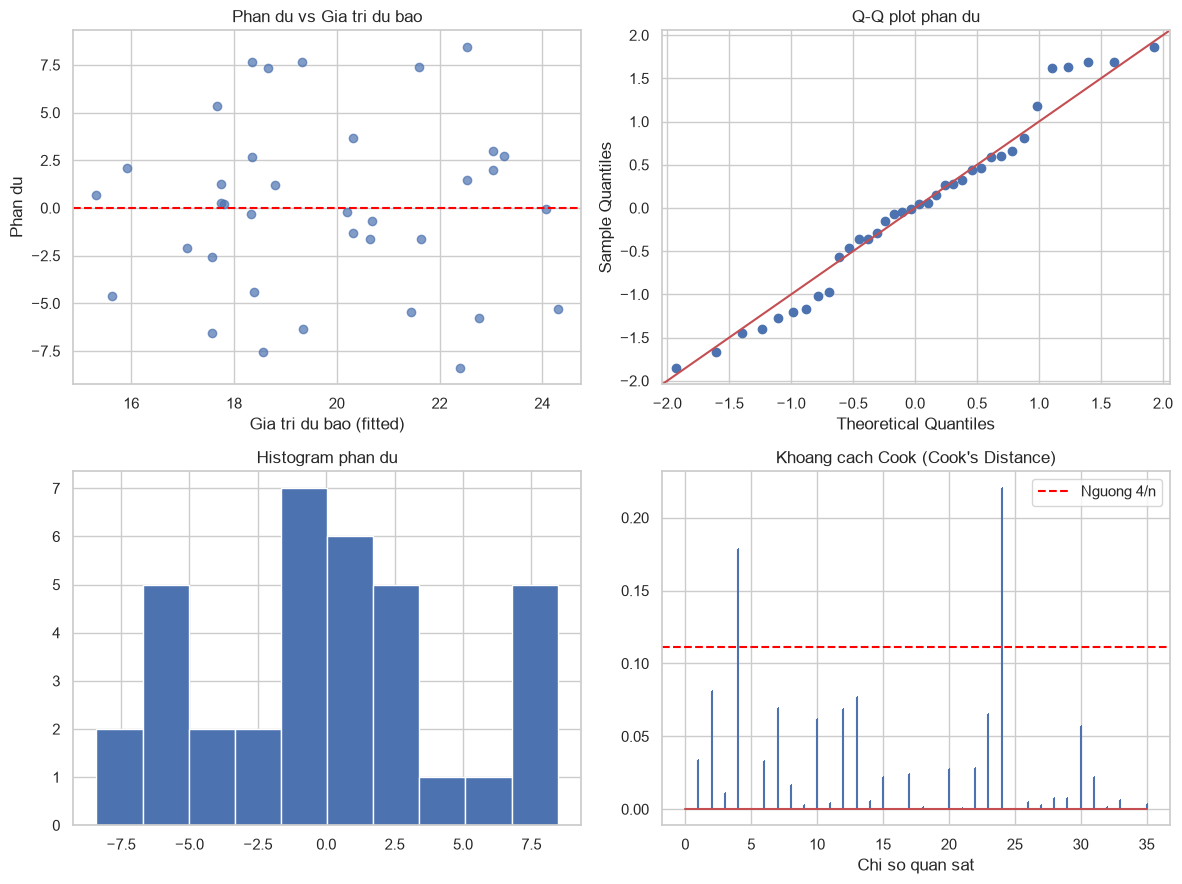

In [15]:
# ===== CHẨN ĐOÁN PHẦN DƯ CỦA MÔ HÌNH OLS =====
fitted = model.fittedvalues              # giá trị dự báo (y-hat) từ mô hình
resid = model.resid                      # phần dư = y thực tế - y dự báo
influence = model.get_influence()        # đối tượng chứa các chỉ số ảnh hưởng (leverage, Cook's D...)
standardized_resid = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]    # khoảng cách Cook cho từng quan sát

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (1) Phần dư vs giá trị dự báo: kiểm tra tính tuyến tính & phương sai đồng nhất (không có hình dạng hệ thống)
axes[0, 0].scatter(fitted, resid, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Gia tri du bao (fitted)')
axes[0, 0].set_ylabel('Phan du')
axes[0, 0].set_title('Phan du vs Gia tri du bao')

# (2) Q-Q plot: kiểm tra phần dư có tuân theo phân phối chuẩn không (điểm nằm sát đường 45 độ)
sm.qqplot(resid, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Q-Q plot phan du')

# (3) Histogram phần dư: hình dạng phân phối trực quan
axes[1, 0].hist(resid, bins=10, edgecolor='white')
axes[1, 0].set_title('Histogram phan du')

# (4) Khoảng cách Cook: phát hiện quan sát có ảnh hưởng lớn đến hệ số hồi quy (ngưỡng tham khảo 4/n)
axes[1, 1].stem(range(len(cooks_d)), cooks_d, markerfmt=',')
axes[1, 1].set_title("Khoang cach Cook (Cook's Distance)")
axes[1, 1].axhline(4 / len(df), color='red', linestyle='--', label='Nguong 4/n')
axes[1, 1].set_xlabel('Chi so quan sat')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_residual_diagnostics.png', dpi=150)
plt.show()


In [16]:
# Kiểm định Shapiro-Wilk: H0 = phần dư tuân theo phân phối chuẩn (p >= 0.05 -> không bác bỏ H0)
shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk test phan du: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
print("-> Phan du", "co ve phan phoi chuan (p >= 0.05)" if shapiro_p >= 0.05 else "khong phan phoi chuan (p < 0.05)")

# Kiểm định Breusch-Pagan: H0 = phương sai phần dư đồng nhất (không có heteroscedasticity)
bp_stat, bp_p, _, _ = sm.stats.diagnostic.het_breuschpagan(resid, X)
print(f"\nBreusch-Pagan test (phuong sai dong nhat): LM stat = {bp_stat:.4f}, p = {bp_p:.4f}")
print("->", "Khong co bang chung phuong sai thay doi (p >= 0.05)" if bp_p >= 0.05 else "Co dau hieu phuong sai thay doi (p < 0.05)")


Shapiro-Wilk test phan du: W = 0.9654, p = 0.3131
-> Phan du co ve phan phoi chuan (p >= 0.05)

Breusch-Pagan test (phuong sai dong nhat): LM stat = 3.3543, p = 0.3402
-> Khong co bang chung phuong sai thay doi (p >= 0.05)


In [17]:
# Liệt kê 5 thành phố có khoảng cách Cook lớn nhất (ảnh hưởng mạnh nhất đến hệ số hồi quy)
df['Cooks_D'] = cooks_d
top_influence = df[['City', 'Walk', 'Bank', 'Talk', 'Heart', 'Cooks_D']].sort_values('Cooks_D', ascending=False).head(5)
top_influence


,City,Walk,Bank,Talk,Heart,Cooks_D
24,Chattanooga,14,34,22,27,0.221
4,Columbus,22,27,30,26,0.179
2,New York,24,29,18,31,0.081
13,Bakersfield,18,29,25,11,0.077
7,Springfield,30,28,21,19,0.069


## 7. Hồi quy đơn biến với chỉ số nhịp sống tổng hợp

Ngoài mô hình 3 biến, ta chạy thêm hồi quy đơn giản `Heart ~ Pace_Index` — dễ diễn giải hơn và cho một
con số tổng hợp duy nhất để trả lời trực tiếp câu hỏi nghiên cứu.

In [18]:
# ===== Hồi quy đơn biến (OLS) với chỉ số nhịp sống tổng hợp Pace_Index =====
X_simple = sm.add_constant(df['Pace_Index'])   # ma trận thiết kế: hằng số + Pace_Index
model_simple = sm.OLS(df['Heart'], X_simple).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:                  Heart   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.023
Method:                 Least Squares   F-statistic:                    0.2051
Date:                Thu, 08 Oct 2026   Prob (F-statistic):              0.653
Time:                        11:39:19   Log-Likelihood:                -109.92
No. Observations:                  36   AIC:                             223.8
Df Residuals:                      34   BIC:                             227.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.8056      0.879     22.529      0.0

## 8. Ước lượng hồi quy tuyến tính Bayes

Ở mục 6–7, mô hình được ước lượng theo trường phái **tần suất** (OLS): hệ số hồi quy là các hằng số chưa
biết được ước lượng bằng một điểm, và ý nghĩa thống kê đánh giá qua p-value. Mục này ước lượng **cùng một
mô hình** theo trường phái **Bayes**: các tham số `β` và `σ²` được coi là **biến ngẫu nhiên**, ta bắt đầu
từ một phân phối tiên nghiệm (prior), cập nhật bằng dữ liệu qua hàm hợp lý (likelihood) để thu được phân
phối **hậu nghiệm** (posterior) — nêu đầy đủ độ bất định của từng tham số, không chỉ một điểm ước lượng.

Công thức nền tảng (định lý Bayes):

```
p(β, σ² | y, X)  ∝  p(y | X, β, σ²) · p(β, σ²)
   hậu nghiệm       hàm hợp lý           prior
```

### 8.1. Thiết lập mô hình Bayes

**Hàm hợp lý (likelihood):** `y = Xβ + ε`, `ε ~ N(0, σ²·I)`, tức `y | X, β, σ² ~ N(Xβ, σ²·I)`, trong đó `X`
là ma trận thiết kế (cột hằng số + Walk + Bank + Talk), `y` là vector `Heart`, `n = 36`, `p = 4`.

**Prior liên hợp Normal-Inverse-Gamma (NIG):**

- `β | σ² ~ N(β₀, σ²·V₀)` — prior cho vector hệ số hồi quy.
- `σ² ~ Inverse-Gamma(a₀, b₀)` — prior cho phương sai sai số.

"Liên hợp" (conjugate) nghĩa là hậu nghiệm cũng thuộc họ NIG, nên có công thức dạng đóng.

**Chọn siêu tham số (weakly informative / prior mở):** `β₀ = 0`, `V₀ = 1000·I` (phương sai prior rất lớn,
gần như không áp đặt giá trị nào cho hệ số), `a₀ = b₀ = 0.001` (xấp xỉ prior Jeffreys cho `σ²`). Lý do:
không có thông tin tiên nghiệm đáng tin về hệ số hồi quy giữa nhịp sống và bệnh tim, nên để dữ liệu quyết
định hậu nghiệm. Hệ quả có chủ đích: kết quả Bayes sẽ gần sát OLS, cho phép **đối chiếu để kiểm tra tính
đúng đắn** của thuật toán.

### 8.2. Hậu nghiệm dạng đóng (closed-form)

Do tính liên hợp, hậu nghiệm là NIG với tham số:

```
Vn    = (V0⁻¹ + X'X)⁻¹
βn    = Vn (V0⁻¹ β0 + X'y)
an    = a0 + n/2
bn    = b0 + ½ ( y'y + β0' V0⁻¹ β0 − βn' Vn⁻¹ βn )
```

`βn` chính là trung bình hậu nghiệm của `β`. Khi prior rất mở (`V₀ → ∞`), `βn` tiến tới nghiệm OLS.

In [19]:
def bayes_posterior_analytic(X, y, beta0=None, V0_scale=1000.0, a0=1e-3, b0=1e-3):
    """Hậu nghiệm dạng đóng của hồi quy tuyến tính Bayes với prior liên hợp Normal-Inverse-Gamma."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape
    if beta0 is None:
        beta0 = np.zeros(p)                       # prior mean của beta: vector 0 (không thiên kiến)
    V0_inv = np.linalg.inv(V0_scale * np.eye(p))   # nghịch đảo ma trận hiệp phương sai prior V0 = 1000*I
    # Công thức hậu nghiệm NIG (liên hợp): Vn = (V0^-1 + X'X)^-1
    Vn = np.linalg.inv(V0_inv + X.T @ X)
    # beta_n = Vn (V0^-1 * beta0 + X'y)  -- trung bình hậu nghiệm của beta
    beta_n = Vn @ (V0_inv @ beta0 + X.T @ y)
    an = a0 + n / 2                                 # tham số shape hậu nghiệm của sigma^2
    # tham số scale hậu nghiệm của sigma^2 (công thức NIG chuẩn)
    bn = b0 + 0.5 * (y @ y + beta0 @ V0_inv @ beta0 - beta_n @ np.linalg.inv(Vn) @ beta_n)
    return {'Vn': Vn, 'beta_n': beta_n, 'an': an, 'bn': bn}

# Tính hậu nghiệm dạng đóng và so sánh trực tiếp với hệ số OLS đã ước lượng ở mục 6
post_analytic = bayes_posterior_analytic(X.values, y.values)
compare = pd.DataFrame({'OLS (tan suat)': model.params.values,
                        'Trung binh hau nghiem (Bayes, closed-form)': post_analytic['beta_n']},
                       index=X.columns)
compare


,OLS (tan suat),"Trung binh hau nghiem (Bayes, closed-form)"
const,3.179,3.173
Walk,0.452,0.452
Bank,0.405,0.405
Talk,-0.180,-0.180


**Nhận xét:** trung bình hậu nghiệm dạng đóng khớp gần như tuyệt đối với hệ số OLS — đúng như kỳ vọng với
prior mở, đồng thời xác nhận công thức được cài đặt chính xác. Điểm khác biệt của Bayes không nằm ở điểm
ước lượng mà ở **toàn bộ phân phối hậu nghiệm** (khoảng tin cậy Bayes, xác suất hậu nghiệm) như trình bày
tiếp theo.

### 8.3. Lấy mẫu hậu nghiệm bằng Gibbs sampling (MCMC)

Để minh hoạ **quá trình** ước lượng Bayes bằng mô phỏng (thay vì chỉ dùng công thức đóng), ta cài đặt
thuật toán **Gibbs sampling** — một dạng Markov Chain Monte Carlo (MCMC). Ý tưởng: thay vì lấy mẫu trực
tiếp từ hậu nghiệm chung `p(β, σ² | y)`, ta luân phiên lấy mẫu từ hai phân phối điều kiện đầy đủ (full
conditional), mỗi phân phối đều có dạng đã biết:

```
σ² | β, y   ~  Inverse-Gamma( a0 + (n+p)/2 ,  b0 + ½ [ (y−Xβ)'(y−Xβ) + (β−β0)' V0⁻¹ (β−β0) ] )
β  | σ², y  ~  N( βn ,  σ² · Vn )
```

Lặp lại nhiều lần, chuỗi (β, σ²) hội tụ về phân phối hậu nghiệm. Ta chạy **4 chain độc lập** với điểm khởi
tạo khác nhau, mỗi chain **6000 vòng lặp**, **bỏ 1000 vòng đầu (burn-in)** vì chuỗi chưa ổn định.

In [20]:
def gibbs_bayes_linear_regression(X, y, beta0=None, V0_scale=1000.0, a0=1e-3, b0=1e-3,
                                   n_iter=6000, burn_in=1000, n_chains=4, seed=42):
    """Lấy mẫu hậu nghiệm (beta, sigma^2) bằng thuật toán Gibbs sampling (MCMC)
    cho hồi quy tuyến tính Bayes với prior liên hợp Normal-Inverse-Gamma.
    Chạy nhiều chain độc lập để phục vụ chẩn đoán hội tụ (Gelman-Rubin R-hat) ở bước sau."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape
    if beta0 is None:
        beta0 = np.zeros(p)
    V0_inv = np.linalg.inv(V0_scale * np.eye(p))
    Vn = np.linalg.inv(V0_inv + X.T @ X)        # hiệp phương sai hậu nghiệm cố định (không đổi theo vòng lặp)
    beta_n = Vn @ (V0_inv @ beta0 + X.T @ y)    # trung bình hậu nghiệm cố định của beta

    rng = np.random.default_rng(seed)           # bộ sinh số ngẫu nhiên, có seed để tái lập kết quả
    chains_beta = np.zeros((n_chains, n_iter, p))
    chains_sigma2 = np.zeros((n_chains, n_iter))
    for c in range(n_chains):
        beta_curr = beta_n + rng.normal(scale=8.0, size=p)   # điểm khởi tạo khác nhau giữa các chain
        for t in range(n_iter):
            # Bước 1: lấy mẫu sigma^2 | beta, y  ~  Inverse-Gamma(a_n, b_n) (với beta hiện tại)
            resid = y - X @ beta_curr
            diff = beta_curr - beta0
            a_n = a0 + (n + p) / 2
            b_n = b0 + 0.5 * (resid @ resid + diff @ V0_inv @ diff)
            sigma2_curr = 1.0 / rng.gamma(shape=a_n, scale=1.0 / b_n)     # sigma^2 | beta, y
            # Bước 2: lấy mẫu beta | sigma^2, y  ~  N(beta_n, sigma^2 * Vn) (với sigma^2 vừa lấy ở bước 1)
            beta_curr = rng.multivariate_normal(beta_n, sigma2_curr * Vn)  # beta | sigma^2, y
            # Lưu lại mẫu của vòng lặp này (gồm cả phần burn-in, sẽ loại bỏ sau)
            chains_beta[c, t] = beta_curr
            chains_sigma2[c, t] = sigma2_curr
    return {'chains_beta': chains_beta, 'chains_sigma2': chains_sigma2, 'burn_in': burn_in}

# Chạy Gibbs sampling cho mô hình 3 biến Heart ~ Walk + Bank + Talk
gibbs_main = gibbs_bayes_linear_regression(X.values, y.values)
print('Da chay xong Gibbs sampling: 4 chain x 6000 vong lap (bo 1000 vong burn-in) cho Heart ~ Walk + Bank + Talk.')


Da chay xong Gibbs sampling: 4 chain x 6000 vong lap (bo 1000 vong burn-in) cho Heart ~ Walk + Bank + Talk.


### 8.4. Chẩn đoán hội tụ (trace plot và Gelman-Rubin R-hat)

Kết quả MCMC chỉ đáng tin nếu các chain đã hội tụ. Có hai kiểm tra chuẩn:

- **Trace plot:** vẽ giá trị tham số theo vòng lặp cho từng chain. Nếu hội tụ, các chain dao động quanh
  cùng một mức và **chồng lấn lên nhau** (không trôi dạt, không tách rời).
- **Gelman-Rubin R-hat:** so sánh phương sai *giữa* các chain với phương sai *trong* từng chain. R-hat ≈ 1
  (thường dùng ngưỡng < 1.05, chặt hơn < 1.01) cho thấy các chain cùng mô tả một phân phối.

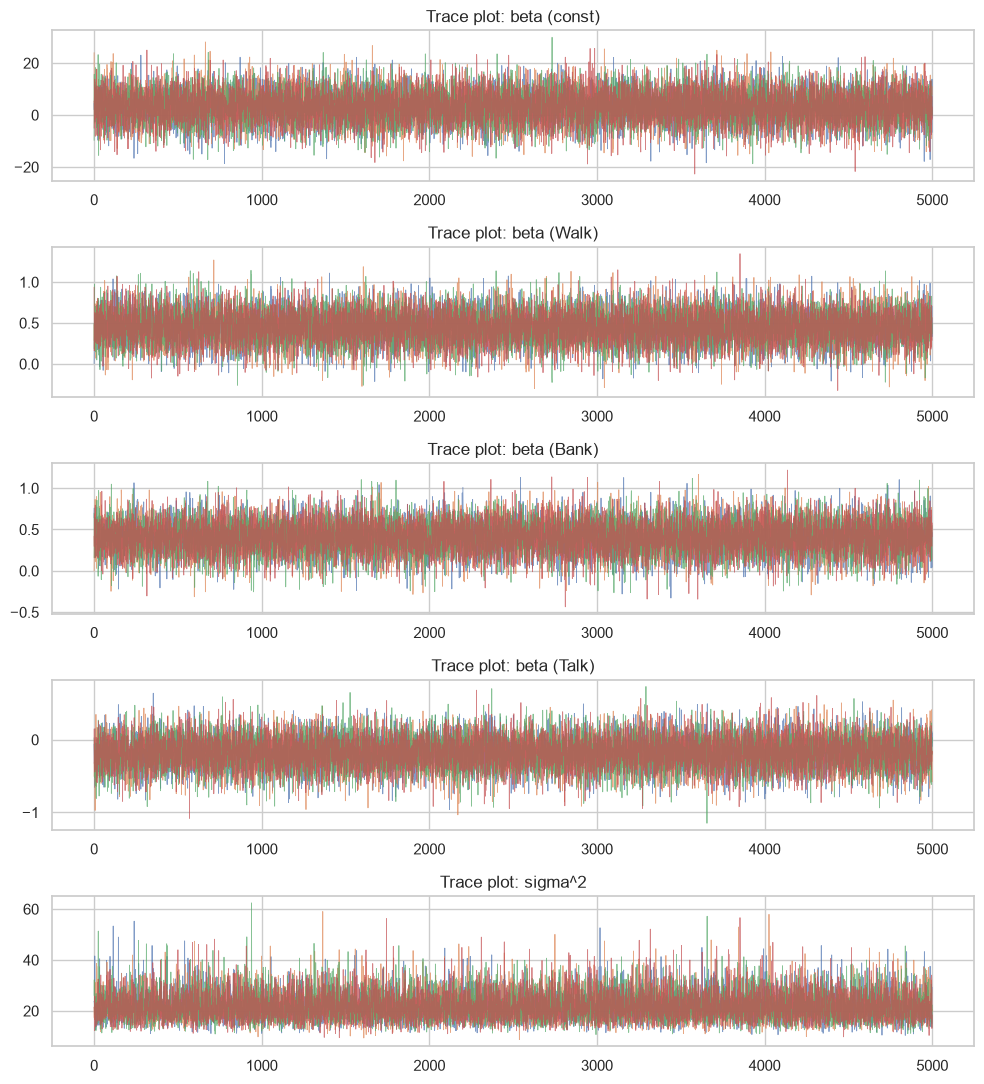

Tham so        R-hat (Gelman-Rubin)
------------------------------------
const                        1.0000
Walk                         1.0000
Bank                         0.9999
Talk                         1.0002
sigma^2                      1.0003


In [21]:
def gelman_rubin(chains_2d):
    """Tính chỉ số Gelman-Rubin R-hat từ mảng (số_chain, số_mẫu) đã bỏ burn-in.
    R-hat ~ 1 cho thấy các chain đã hội tụ về cùng một phân phối hậu nghiệm."""
    m, n = chains_2d.shape
    chain_means = chains_2d.mean(axis=1)          # trung bình của từng chain
    chain_vars = chains_2d.var(axis=1, ddof=1)    # phương sai TRONG từng chain
    W = chain_vars.mean()                          # phương sai trung bình trong nội bộ các chain (within)
    B = n * chain_means.var(ddof=1)                # phương sai GIỮA các chain (between), nhân với n
    var_hat = (1 - 1 / n) * W + B / n              # ước lượng phương sai hậu nghiệm tổng hợp
    return np.sqrt(var_hat / W) if W > 0 else np.nan

param_names = list(X.columns)
burn_in = gibbs_main['burn_in']
post_beta = gibbs_main['chains_beta'][:, burn_in:, :]   # bỏ burn-in, giữ lại mẫu đã "ổn định"
post_sigma2 = gibbs_main['chains_sigma2'][:, burn_in:]

# Trace plot: vẽ giá trị tham số qua từng vòng lặp cho cả 4 chain - các chain phải "chồng lấn" nhau
fig, axes = plt.subplots(len(param_names) + 1, 1, figsize=(10, 2.2 * (len(param_names) + 1)))
for j, name in enumerate(param_names):
    for c in range(post_beta.shape[0]):
        axes[j].plot(post_beta[c, :, j], alpha=0.7, linewidth=0.6)
    axes[j].set_title(f'Trace plot: beta ({name})')
for c in range(post_sigma2.shape[0]):
    axes[-1].plot(post_sigma2[c], alpha=0.7, linewidth=0.6)
axes[-1].set_title('Trace plot: sigma^2')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_bayes_trace_plots.png', dpi=150)
plt.show()

# In bảng R-hat cho từng tham số (beta0..beta3 và sigma^2)
print(f"{'Tham so':12s} {'R-hat (Gelman-Rubin)':>22s}")
print('-' * 36)
for j, name in enumerate(param_names):
    print(f"{name:12s} {gelman_rubin(post_beta[:, :, j]):22.4f}")
print(f"{'sigma^2':12s} {gelman_rubin(post_sigma2):22.4f}")


**Nhận xét:** nếu tất cả R-hat xấp xỉ 1.000 và trace plot của 4 chain chồng lấn nhau, các chain đã hội tụ về
cùng một phân phối hậu nghiệm và mẫu thu được (4 × 5000 = 20.000 mẫu sau burn-in) đáng tin cậy để tổng hợp.

### 8.5. Tổng hợp hậu nghiệm và đối chiếu với OLS

Từ các mẫu hậu nghiệm, ta tính với mỗi hệ số:

- **Trung bình / độ lệch chuẩn hậu nghiệm:** điểm ước lượng và độ bất định.
- **Khoảng tin cậy Bayes 95% (credible interval):** khoảng chứa hệ số với xác suất 95% *theo hậu nghiệm* —
  diễn giải trực tiếp hơn khoảng tin cậy tần suất.
- **`P(β > 0 | dữ liệu)`:** xác suất hậu nghiệm để hệ số dương. Đây là câu trả lời trực tiếp cho câu hỏi "tác
  động có cùng chiều với giả thuyết không?", không cần ngưỡng p-value tuỳ ý.

In [22]:
# Gộp (pool) mẫu hậu nghiệm của cả 4 chain lại thành 1 tập mẫu duy nhất (sau khi đã bỏ burn-in)
pooled_beta = post_beta.reshape(-1, post_beta.shape[-1])
rows = []
for j, name in enumerate(param_names):
    s = pooled_beta[:, j]   # toàn bộ mẫu hậu nghiệm của hệ số thứ j
    rows.append({
        'Bien': name,
        'OLS_coef': model.params[name],              # hệ số OLS để đối chiếu
        'OLS_se': model.bse[name],
        'Bayes_mean': s.mean(),                        # trung bình hậu nghiệm (điểm ước lượng Bayes)
        'Bayes_sd': s.std(ddof=1),                      # độ lệch chuẩn hậu nghiệm (độ bất định)
        'CI_2.5%': np.percentile(s, 2.5),               # cận dưới khoảng tin cậy Bayes 95%
        'CI_97.5%': np.percentile(s, 97.5),             # cận trên khoảng tin cậy Bayes 95%
        'P(beta>0|data)': (s > 0).mean(),               # xác suất hậu nghiệm hệ số dương
    })
bayes_summary = pd.DataFrame(rows).set_index('Bien')
bayes_summary


,OLS_coef,OLS_se,Bayes_mean,Bayes_sd,CI_2.5%,CI_97.5%,P(beta>0|data)
Bien,,,,,,,
const,3.179,6.337,3.243,6.146,-8.917,15.336,0.703
Walk,0.452,0.201,0.450,0.196,0.063,0.838,0.988
Bank,0.405,0.197,0.405,0.193,0.023,0.783,0.980
Talk,-0.180,0.222,-0.181,0.216,-0.603,0.251,0.195


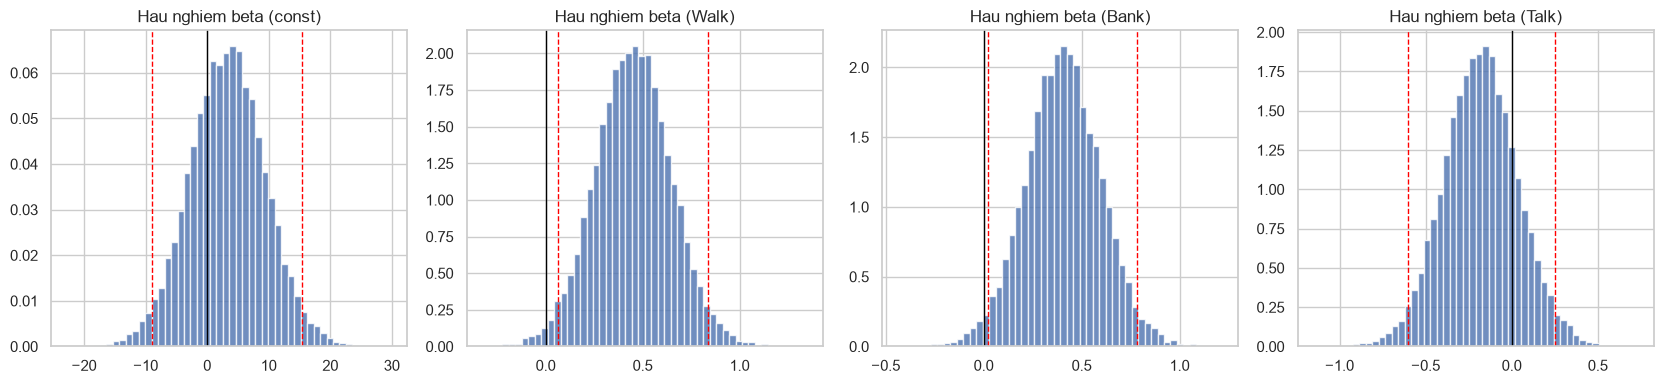

In [23]:
# Vẽ histogram phân phối hậu nghiệm của từng hệ số, đánh dấu khoảng tin cậy 95% và mốc 0
fig, axes = plt.subplots(1, len(param_names), figsize=(4.2 * len(param_names), 4))
for j, (ax, name) in enumerate(zip(axes, param_names)):
    s = pooled_beta[:, j]
    ax.hist(s, bins=50, color='#4C72B0', alpha=0.8, density=True)
    lo, hi = np.percentile(s, [2.5, 97.5])
    ax.axvline(lo, color='red', linestyle='--', linewidth=1)   # cận dưới CI 95%
    ax.axvline(hi, color='red', linestyle='--', linewidth=1)   # cận trên CI 95%
    ax.axvline(0, color='black', linewidth=1)                  # mốc 0 để so sánh chiều tác động
    ax.set_title(f'Hau nghiem beta ({name})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_bayes_posterior_hist.png', dpi=150)
plt.show()


**Cách đọc biểu đồ:** đường đứt đỏ là hai đầu khoảng tin cậy Bayes 95%; đường đen là mốc 0. Hệ số có bằng
chứng hậu nghiệm rõ ràng khi phần lớn khối lượng phân phối nằm về một phía của mốc 0 (khoảng tin cậy không
chứa 0, `P(β>0|data)` gần 1 hoặc gần 0).

### 8.6. Ước lượng Bayes cho mô hình đơn biến với `Pace_Index`

Áp dụng cùng thuật toán cho mô hình `Heart ~ Pace_Index` (mục 7) để có đối chiếu Bayes cho chỉ số tổng hợp.

In [24]:
# Áp dụng lại cùng thuật toán Gibbs sampling cho mô hình đơn biến Heart ~ Pace_Index
gibbs_simple = gibbs_bayes_linear_regression(X_simple.values, df['Heart'].values)
post_simple = gibbs_simple['chains_beta'][:, gibbs_simple['burn_in']:, :].reshape(-1, 2)
rows = []
for j, name in enumerate(['const', 'Pace_Index']):
    s = post_simple[:, j]
    rows.append({'Bien': name, 'OLS_coef': model_simple.params[name], 'Bayes_mean': s.mean(),
                 'Bayes_sd': s.std(ddof=1), 'CI_2.5%': np.percentile(s, 2.5),
                 'CI_97.5%': np.percentile(s, 97.5), 'P(beta>0|data)': (s > 0).mean()})
simple_summary = pd.DataFrame(rows).set_index('Bien')
simple_summary


,OLS_coef,Bayes_mean,Bayes_sd,CI_2.5%,CI_97.5%,P(beta>0|data)
Bien,,,,,,
const,19.806,19.81,0.886,18.063,21.544,1.000
Pace_Index,0.712,0.71,1.575,-2.362,3.841,0.678


## 9. Đánh giá kết quả và kết luận

In [25]:
# ===== TỔNG HỢP CUỐI CÙNG: đối chiếu bằng chứng tần suất (Pearson/OLS) và Bayes (hậu nghiệm) =====
r_walk, p_walk = stats.pearsonr(df['Walk'], df['Heart'])
r_bank, p_bank = stats.pearsonr(df['Bank'], df['Heart'])
r_talk, p_talk = stats.pearsonr(df['Talk'], df['Heart'])
r_pace, p_pace = stats.pearsonr(df['Pace_Index'], df['Heart'])

def nhan_xet(name, r, p, expect_positive=True):
    """So sánh chiều dấu + ý nghĩa thống kê của 1 biến với chiều kỳ vọng bởi giả thuyết type-A."""
    sig = p < 0.05
    khop = (r > 0) == expect_positive
    if sig and khop:
        return f'{name}: ỦNG HỘ giả thuyết, có ý nghĩa thống kê (r={r:+.3f}, p={p:.3f})'
    if sig and not khop:
        return f'{name}: NGƯỢC với giả thuyết, có ý nghĩa thống kê (r={r:+.3f}, p={p:.3f})'
    if khop:
        return f'{name}: đúng chiều giả thuyết nhưng KHÔNG có ý nghĩa thống kê (r={r:+.3f}, p={p:.3f})'
    return f'{name}: ngược chiều giả thuyết và KHÔNG có ý nghĩa thống kê (r={r:+.3f}, p={p:.3f})'

print('=' * 84)
print('TÓM TẮT KẾT QUẢ (TẦN SUẤT + BAYES)')
print('=' * 84)
print('--- Tần suất (Pearson) so với kỳ vọng type-A: Walk cao, Talk cao, Bank THẤP => Heart cao ---')
print(' -', nhan_xet('Walk', r_walk, p_walk, True))
print(' -', nhan_xet('Talk', r_talk, p_talk, True))
print(' -', nhan_xet('Bank', r_bank, p_bank, False))
print(f"\n--- Hồi quy bội OLS: R2 = {model.rsquared:.4f}, Adj R2 = {model.rsquared_adj:.4f}, F = {model.fvalue:.3f}, p = {model.f_pvalue:.4g}")
print('\n--- Bayes (hậu nghiệm Gibbs sampling) ---')
for name in param_names:
    r = bayes_summary.loc[name]
    print(f"  {name:8s} mean = {r['Bayes_mean']:+.4f}, 95% CI = [{r['CI_2.5%']:+.4f}, {r['CI_97.5%']:+.4f}], P(beta>0|data) = {r['P(beta>0|data)']:.3f}")
print(f"\n--- Pace_Index: r = {r_pace:+.3f}, p = {p_pace:.4f}; OLS R2 = {model_simple.rsquared:.4f}; "
      f"Bayes P(beta>0|data) = {simple_summary.loc['Pace_Index', 'P(beta>0|data)']:.3f}")


TÓM TẮT KẾT QUẢ (TẦN SUẤT + BAYES)
--- Tần suất (Pearson) so với kỳ vọng type-A: Walk cao, Talk cao, Bank THẤP => Heart cao ---
 - Walk: ỦNG HỘ giả thuyết, có ý nghĩa thống kê (r=+0.348, p=0.038)
 - Talk: đúng chiều giả thuyết nhưng KHÔNG có ý nghĩa thống kê (r=+0.100, p=0.562)
 - Bank: ngược chiều giả thuyết và KHÔNG có ý nghĩa thống kê (r=+0.318, p=0.059)

--- Hồi quy bội OLS: R2 = 0.2236, Adj R2 = 0.1509, F = 3.073, p = 0.04162

--- Bayes (hậu nghiệm Gibbs sampling) ---
  const    mean = +3.2432, 95% CI = [-8.9170, +15.3362], P(beta>0|data) = 0.703
  Walk     mean = +0.4502, 95% CI = [+0.0631, +0.8375], P(beta>0|data) = 0.988
  Bank     mean = +0.4048, 95% CI = [+0.0228, +0.7830], P(beta>0|data) = 0.980
  Talk     mean = -0.1808, 95% CI = [-0.6035, +0.2508], P(beta>0|data) = 0.195

--- Pace_Index: r = +0.077, p = 0.6535; OLS R2 = 0.0060; Bayes P(beta>0|data) = 0.678


**Biện luận trả lời câu hỏi nghiên cứu:**

- **Hai trường phái cho kết quả thống nhất:** hệ số OLS và trung bình hậu nghiệm Bayes gần như trùng khớp
  (do prior mở); R-hat ≈ 1 xác nhận thuật toán Gibbs hội tụ. Khác biệt nằm ở cách diễn giải: p-value cho
  biết dữ liệu "bất thường" đến mức nào nếu giả thuyết không đúng, còn `P(β>0|dữ liệu)` cho biết trực tiếp
  mức độ tin vào chiều tác động sau khi thấy dữ liệu.
- **`Walk`** là bằng chứng mạnh và nhất quán nhất: hệ số dương, có ý nghĩa tần suất và xác suất hậu nghiệm
  dương rất cao — ủng hộ giả thuyết type-A (đi bộ nhanh ⇒ tỷ lệ bệnh tim cao hơn).
- **`Bank`** có hệ số dương với xác suất hậu nghiệm cao, nhưng **ngược chiều** dự đoán ("Bank thấp = gấp
  gáp = bệnh tim cao"): thành phố xử lý giao dịch chậm hơn mới có bệnh tim cao hơn. Đây là phát hiện thực
  nghiệm, không phải lỗi tính toán.
- **`Talk`** có hệ số âm, khoảng tin cậy Bayes chứa 0 và `P(β>0|dữ liệu)` thấp — không có bằng chứng rõ
  ràng khi đã kiểm soát Walk và Bank.
- **`Pace_Index`** (giả định Bank thấp = gấp gáp) không phải thước đo phù hợp với dữ liệu này: thành phần
  Bank triệt tiêu tín hiệu của Walk; cả OLS lẫn Bayes đều cho khoảng tin cậy rất rộng, chứa 0.

**Kết luận:** dữ liệu **ủng hộ một phần, không dứt khoát** niềm tin rằng cảm giác gấp gáp về thời gian đi
kèm nguy cơ bệnh tim cao hơn; bằng chứng mạnh nhất đến từ tốc độ đi bộ (`Walk`), được xác nhận độc lập bởi
cả kiểm định tần suất lẫn xác suất hậu nghiệm Bayes.

**Các giới hạn cần lưu ý:**

1. **Cỡ mẫu nhỏ** (36 thành phố) làm tăng độ bất định ở cả hai trường phái (khoảng tin cậy rộng).
2. **Dữ liệu cấp độ tổng hợp (ecological data):** chỉ số là đại diện của thành phố, không đo trên từng cá
   nhân — có nguy cơ *ecological fallacy*, không suy trực tiếp nhân quả ở cấp cá nhân.
3. **Tương quan không suy ra nhân quả:** các yếu tố gây nhiễu (khí hậu, chế độ ăn, thu nhập, hút thuốc,
   chăm sóc y tế, cơ cấu tuổi...) không được kiểm soát.
4. **Prior mở được chọn có chủ đích** để đối chiếu với OLS; nếu có thông tin tiên nghiệm thực tế, kết quả
   Bayes có thể khác và cần phân tích độ nhạy (sensitivity analysis) với các prior khác.
5. **R² của mô hình OLS** cho biết phần lớn biến thiên của tỷ lệ bệnh tim vẫn do các yếu tố khác quyết
   định.